# Model 1: A school of 20 fish through time

Each fish is baseline (0) or escaping (1). The mean of these binary states is the **fraction escaping**, between 0 and 1. The field is `exposed[fish] * stimulus + J * activity - threshold`. Escaping fish add positive social input; baseline fish add zero. This replaces the signed mean-spin coupling in the original brief.

During each step, baseline fish that are not refractory are visited in random order and activate with probability `1 / (1 + exp(-beta * field))`. Later fish see earlier activations. Any escaping fish increases the probability for those visited next; a majority is not required for positive social input. Whether a small seed grows into a cascade still depends on coupling, threshold, noise, and escape duration.

The threat pulse starts at `stimulus_start`, lasts `stimulus_duration` steps, and reaches only **`n_exposed` randomly selected fish** (default: 3). This subset stays fixed for the entire run. Other fish receive no direct stimulus, but can activate through social input and baseline noise. Exposure increases activation probability; it does not force escape. Escapes last `escape_duration` steps. After recovery, fish spend `refractory_duration` full steps at baseline before they can activate again. Refractory fish contribute no social activity. Stronger coupling (`J = 3.0`) and lower noise (`beta = 24.0`) allow the three exposed fish to recruit the school; the refractory period ends the response. Fish already escaping at the start of a step only advance their recovery timer; they cannot reactivate that step. New escapes start their timers without immediately decrementing them. Each fish stores its own recovery timer. Each recorded column is the state after one update step, including column 0; the initial state is not retained separately. All fish start at baseline, and the simulation uses a fixed random seed. Run the cells in order to reset the simulation.


In [25]:
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
import numpy as np

from agent import Agent
from stimulus import square_wave

In [26]:
# Simulation parameters
n_fish = 20
total_timesteps = 200
random_seed = 2026
n_exposed = 5

# Agent parameters
J = 1.
beta = 10.0
threshold = 0.5
escape_duration = 5
refractory_duration = 10

# Stimulus parameters
stimulus_start = 10
stimulus_strength = 1
stimulus_duration = 5


In [27]:
# Initialise n_fish number of agents
rng = np.random.default_rng(random_seed)
agents = np.array([Agent() for _ in range(n_fish)])
for agent in agents:
    agent.spin = 0

# Select a fixed subset that receives the direct stimulus
exposed = np.zeros(n_fish, dtype=bool)
exposed[rng.choice(n_fish, size=n_exposed, replace=False)] = True

In [28]:
# Create stimulus and state history arrays
time = np.arange(total_timesteps)
stimulus = square_wave(time - stimulus_start, stimulus_strength, stimulus_duration)
state_history = np.empty((n_fish, len(time)), dtype=np.int8)
state_history[:, 0] = [agent.spin for agent in agents]

In [29]:
# Run the simulation
for t in range(total_timesteps):
    already_escaping = np.array([agent.spin == 1 for agent in agents])
    already_refractory = np.array([agent.refractory_timer > 0 for agent in agents])
    eligible = ~(already_escaping | already_refractory)
    active_count = int(already_escaping.sum())

    # Random sequential updates: the field changes after each new escape
    for fish in rng.permutation(np.flatnonzero(eligible)):
        activity = active_count / n_fish

        # Only exposed fish receive the external threat pulse
        direct_stimulus = stimulus[t] if exposed[fish] else 0.0
        field = direct_stimulus + J * activity - threshold
        
        probability = 1 / (1 + np.exp(-beta * field))
        if rng.random() < probability:
            agents[fish].spin = 1
            agents[fish].recovery_timer = escape_duration
            active_count += 1

    # Advance existing refractory timers before assigning newly recovered fish
    for fish in np.flatnonzero(already_refractory):
        agents[fish].refractory_timer -= 1

    for fish in np.flatnonzero(already_escaping):
        agents[fish].recovery_timer -= 1
        if agents[fish].recovery_timer == 0:
            agents[fish].spin = 0
            agents[fish].refractory_timer = refractory_duration

    state_history[:, t] = [agent.spin for agent in agents]

/var/folders/0g/sdxjw2215djd8lwldnn922680000gn/T/ipykernel_74957/623920291.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc="upper right")


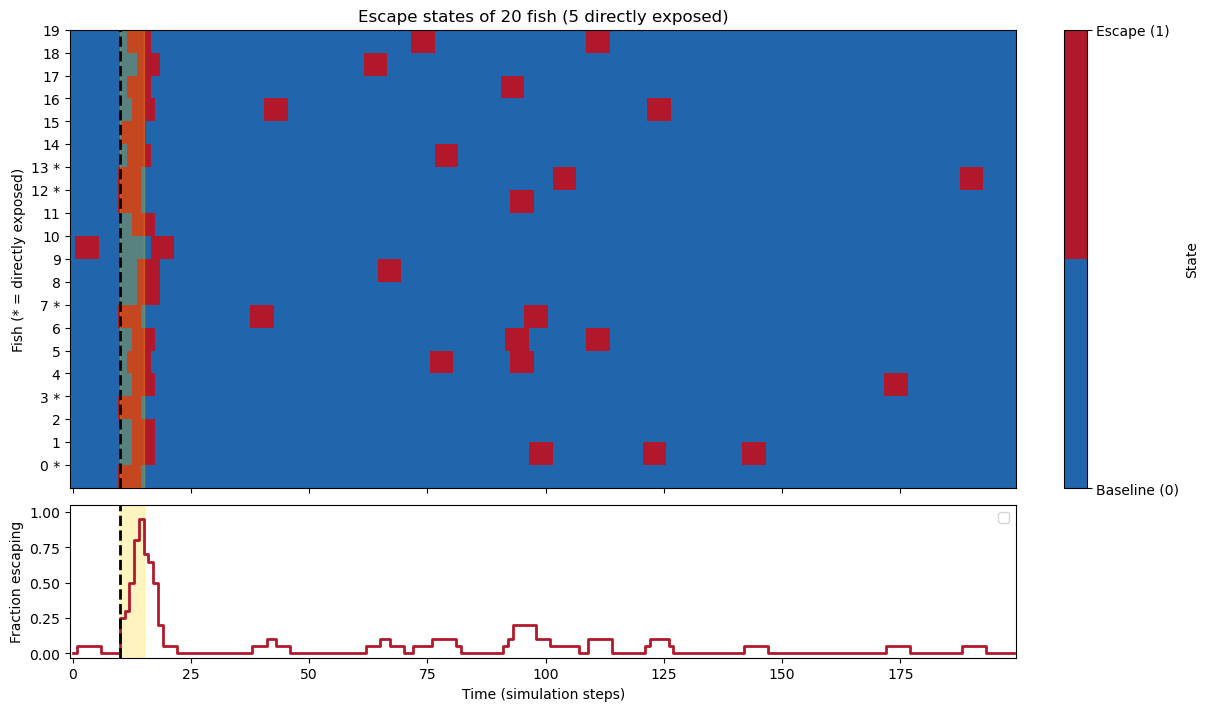

In [30]:
escape_fraction = state_history.mean(axis=0)

fig, (ax1,ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True, constrained_layout=True, gridspec_kw={"height_ratios": [3, 1]})
cmap = ListedColormap(["#2166ac", "#b2182b"])
image = ax1.pcolormesh(np.arange(total_timesteps), np.arange(n_fish) - 0.5, state_history, cmap=cmap)

ax1.set_yticks(np.arange(n_fish))
ax1.set_yticklabels([f"{i} *" if exposed[i] else str(i) for i in range(n_fish)])
ax1.set_ylabel("Fish (* = directly exposed)")
ax1.set_title(f"Escape states of {n_fish} fish ({n_exposed} directly exposed)")
colorbar = fig.colorbar(image, ax=ax1, ticks=[0, 1], label="State")
colorbar.ax.set_yticklabels(["Baseline (0)", "Escape (1)"])

ax2.step(time, escape_fraction, where="post", color="#b2182b", linewidth=2)
ax2.set_ylim(-0.03, 1.05)
ax2.set_ylabel("Fraction escaping")
ax2.set_xlabel("Time (simulation steps)")
ax2.legend(loc="upper right")

for panel in (ax1,ax2):
    panel.axvspan(stimulus_start, stimulus_start + stimulus_duration, color="gold", alpha=0.25)
    panel.axvline(stimulus_start, color="black", linestyle="--", linewidth=2)
plt.show()
